# IMDB Sentiment Classification for NLP Course

This notebook is a complete, assignment-ready project using the IMDB 50K dataset.

## Objectives
- Build classical NLP classifiers for sentiment analysis
- Compare multiple methods taught in class
- Evaluate with robust metrics and error analysis
- Provide interpretable insights for report discussion

## 1: Setup and packages

In [1]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 140)
SEED = 42

## 2. Download IMDB Dataset with kagglehub

The assignment-required download cell is below.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

100%|██████████| 25.7M/25.7M [00:04<00:00, 5.95MB/s]

Extracting files...


Path to dataset files: C:\Users\2004l\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1


In [3]:
csv_files = []
for root, _, files in os.walk(path):
    for f in files:
        if f.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, f))

print("CSV files found:")
for f in csv_files:
    print(" -", f)

if not csv_files:
    raise FileNotFoundError("No CSV file found in downloaded kagglehub path.")

df = pd.read_csv(csv_files[0])
print("Data shape:", df.shape)
df.head()

CSV files found:
 - C:\Users\2004l\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1\IMDB Dataset.csv
Data shape: (50000, 2)


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, a...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a ligh...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human rela...",positive


## 3. Initial Data Quality Checks and EDA

In [4]:
print(df.info())
print("\nNull values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nClass distribution:\n", df["sentiment"].value_counts())

df["review_char_len"] = df["review"].str.len()
df["review_word_len"] = df["review"].str.split().str.len()
display(df[["review_char_len", "review_word_len"]].describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB
None

Null values:
 review       0
sentiment    0
dtype: int64

Duplicate rows: 418

Class distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
review_char_len,50000.0,1309.43102,989.728014,32.0,699.0,970.0,1590.25,13704.0
review_word_len,50000.0,231.15694,171.343997,4.0,126.0,173.0,280.00,2470.0


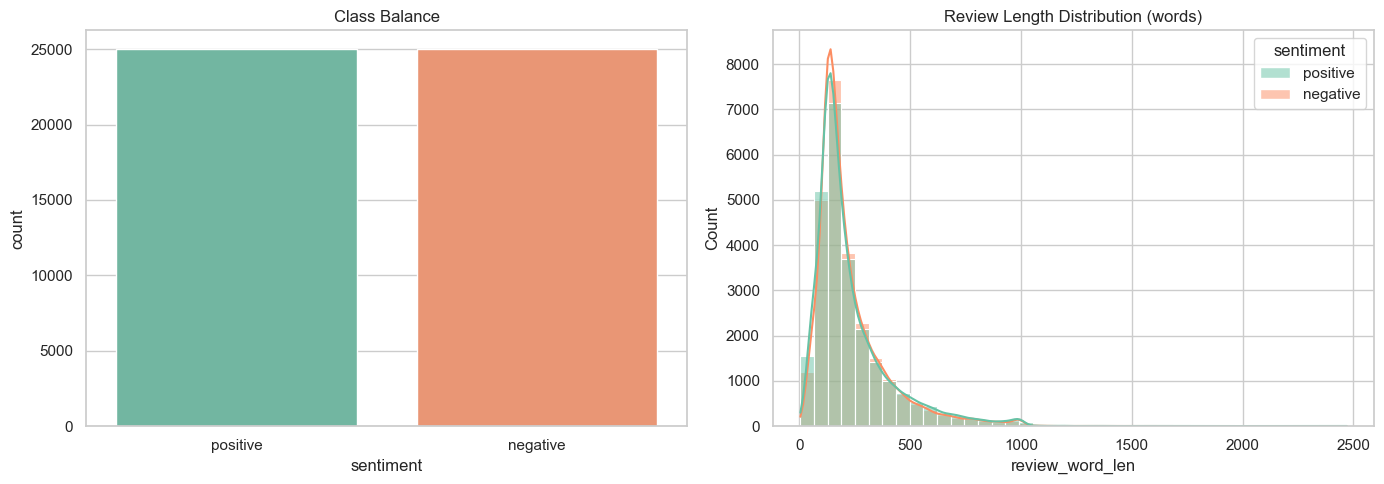

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="sentiment", hue="sentiment", legend=False, ax=axes[0], palette="Set2")
axes[0].set_title("Class Balance")

sns.histplot(data=df, x="review_word_len", hue="sentiment", bins=40, kde=True, ax=axes[1], palette="Set2")
axes[1].set_title("Review Length Distribution (words)")

plt.tight_layout()
plt.show()

## 4. Label Encoding and Train/Validation/Test Split

In [6]:
y = df["sentiment"].map({"negative": 0, "positive": 1})
X_raw = df["review"].astype(str)

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=2/3, random_state=SEED, stratify=y_temp
)

print("Train size:", len(X_train_raw))
print("Validation size:", len(X_val_raw))
print("Test size:", len(X_test_raw))

Train size: 35000
Validation size: 5000
Test size: 10000


## 5. Text Preprocessing Pipeline

We implement two variants:
- Light preprocessing: basic cleaning only
- Aggressive preprocessing: includes stopword removal and lemmatization

In [7]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_light(text: str) -> str:
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_aggressive(text: str) -> str:
    text = clean_light(text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return " ".join(tokens)


tqdm.pandas()
X_train_light = X_train_raw.progress_apply(clean_light)
X_val_light = X_val_raw.progress_apply(clean_light)
X_test_light = X_test_raw.progress_apply(clean_light)

X_train_clean = X_train_raw.progress_apply(clean_aggressive)
X_val_clean = X_val_raw.progress_apply(clean_aggressive)
X_test_clean = X_test_raw.progress_apply(clean_aggressive)

pd.DataFrame({
    "original": X_train_raw.head(3).values,
    "light": X_train_light.head(3).values,
    "aggressive": X_train_clean.head(3).values,
})

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\2004l\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\2004l\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\2004l\AppData\Roaming\nltk_data...


  0%|          | 0/35000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/35000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,original,light,aggressive
0,"If you want to see a true thriller, rent this!!! It's not from the director or screenwriter of ""Scream"", doesn't feature overacting, ove...",if you want to see a true thriller rent this it s not from the director or screenwriter of scream doesn t feature overacting overpaid tv...,want see true thriller rent director screenwriter scream feature overacting overpaid actor passing star run mill special effect bonanza ...
1,"This is one of the first and best Columbos, starring Robert Culp and Ray Milland. Robert Culp appeared on another Columbo, as did severa...",this is one of the first and best columbos starring robert culp and ray milland robert culp appeared on another columbo as did several o...,one first best columbo starring robert culp ray milland robert culp appeared another columbo several villain including patrick mcgoohan ...
2,This was the one movie to see about the Civi War. My aunt actually played in this movie as an extra in the Justin and Madeline wedding s...,this was the one movie to see about the civi war my aunt actually played in this movie as an extra in the justin and madeline wedding sc...,one movie see civi war aunt actually played movie extra justin madeline wedding scene uncle extra horse script genuine accurate costume ...


## 6. Baseline Features: Bag-of-Words and TF-IDF

In [8]:
bow = CountVectorizer(ngram_range=(1, 2), min_df=2, max_features=60000)
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=80000)

X_train_bow = bow.fit_transform(X_train_clean)
X_val_bow = bow.transform(X_val_clean)
X_test_bow = bow.transform(X_test_clean)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf = tfidf.transform(X_val_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print("BoW train shape:", X_train_bow.shape)
print("TF-IDF train shape:", X_train_tfidf.shape)

mem_bow_mb = (X_train_bow.data.nbytes + X_train_bow.indptr.nbytes + X_train_bow.indices.nbytes) / (1024**2)
mem_tfidf_mb = (X_train_tfidf.data.nbytes + X_train_tfidf.indptr.nbytes + X_train_tfidf.indices.nbytes) / (1024**2)
print(f"Approx sparse memory: BoW={mem_bow_mb:.2f} MB, TF-IDF={mem_tfidf_mb:.2f} MB")

BoW train shape: (35000, 60000)
TF-IDF train shape: (35000, 80000)
Approx sparse memory: BoW=48.44 MB, TF-IDF=50.21 MB


## 7. Models: MultinomialNB, Logistic Regression, Linear SVM

In [9]:
def evaluate_model(name, model, X_tr, y_tr, X_va, y_va, X_te, y_te, use_proba=False):
    model.fit(X_tr, y_tr)

    val_pred = model.predict(X_va)
    test_pred = model.predict(X_te)

    val_f1 = f1_score(y_va, val_pred)
    test_f1 = f1_score(y_te, test_pred)

    if use_proba and hasattr(model, "predict_proba"):
        val_score = model.predict_proba(X_va)[:, 1]
        test_score = model.predict_proba(X_te)[:, 1]
        val_auc = roc_auc_score(y_va, val_score)
        test_auc = roc_auc_score(y_te, test_score)
    elif hasattr(model, "decision_function"):
        val_score = model.decision_function(X_va)
        test_score = model.decision_function(X_te)
        val_auc = roc_auc_score(y_va, val_score)
        test_auc = roc_auc_score(y_te, test_score)
    else:
        val_auc = np.nan
        test_auc = np.nan

    return {
        "model": name,
        "val_accuracy": accuracy_score(y_va, val_pred),
        "val_precision": precision_score(y_va, val_pred),
        "val_recall": recall_score(y_va, val_pred),
        "val_f1": val_f1,
        "val_roc_auc": val_auc,
        "test_accuracy": accuracy_score(y_te, test_pred),
        "test_precision": precision_score(y_te, test_pred),
        "test_recall": recall_score(y_te, test_pred),
        "test_f1": test_f1,
        "test_roc_auc": test_auc,
        "fitted_model": model,
        "test_pred": test_pred,
    }


runs = []

runs.append(evaluate_model(
    "MultinomialNB (BoW)",
    MultinomialNB(alpha=0.5),
    X_train_bow, y_train, X_val_bow, y_val, X_test_bow, y_test, use_proba=True
))

runs.append(evaluate_model(
    "MultinomialNB (TFIDF)",
    MultinomialNB(alpha=0.5),
    X_train_tfidf, y_train, X_val_tfidf, y_val, X_test_tfidf, y_test, use_proba=True
))

runs.append(evaluate_model(
    "LogReg (TFIDF)",
    LogisticRegression(max_iter=300, C=2.0, class_weight="balanced", n_jobs=-1),
    X_train_tfidf, y_train, X_val_tfidf, y_val, X_test_tfidf, y_test
))

runs.append(evaluate_model(
    "LinearSVC (TFIDF)",
    LinearSVC(C=1.0),
    X_train_tfidf, y_train, X_val_tfidf, y_val, X_test_tfidf, y_test
))

runs.append(evaluate_model(
    "SGDClassifier (TFIDF)",
    SGDClassifier(loss="hinge", alpha=1e-4, random_state=SEED),
    X_train_tfidf, y_train, X_val_tfidf, y_val, X_test_tfidf, y_test
))

results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ["fitted_model", "test_pred"]} for r in runs])
results_df = results_df.sort_values("test_f1", ascending=False).reset_index(drop=True)
results_df

c:\Users\2004l\Desktop\Movie-classificator\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,model,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,LinearSVC (TFIDF),0.9018,0.900359,0.9036,0.901976,0.965608,0.9066,0.900828,0.9138,0.907268,0.967190
1,LogReg (TFIDF),0.8984,0.892744,0.9056,0.899126,0.963631,0.9061,0.897592,0.9168,0.907094,0.966403
2,SGDClassifier (TFIDF),0.8954,0.887192,0.9060,0.896497,0.961408,0.9045,0.893100,0.9190,0.905865,0.964380
3,MultinomialNB (TFIDF),0.8810,0.878126,0.8848,0.881450,0.950035,0.8864,0.880465,0.8942,0.887279,0.952582
4,MultinomialNB (BoW),0.8674,0.870214,0.8636,0.866894,0.932770,0.8775,0.877123,0.8780,0.877561,0.938611


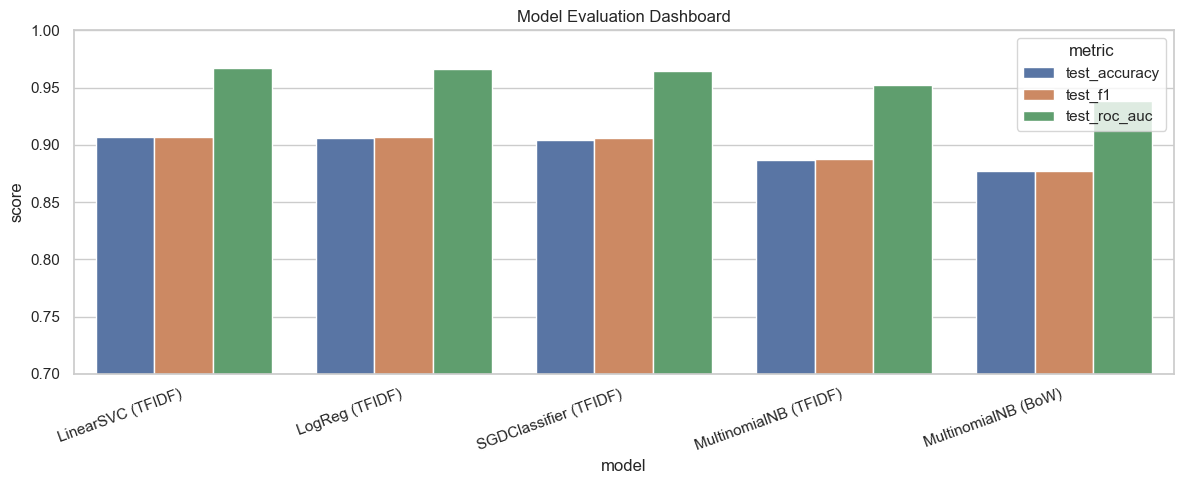

In [10]:
plt.figure(figsize=(12, 5))
plot_df = results_df[["model", "test_accuracy", "test_f1", "test_roc_auc"]].melt(id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.xticks(rotation=20, ha="right")
plt.ylim(0.7, 1.0)
plt.title("Model Evaluation Dashboard")
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning with Cross-Validation

In [11]:
tune_pipe = Pipeline([
    ("vec", TfidfVectorizer()),
    ("clf", LinearSVC())
])

param_grid = {
    "vec__ngram_range": [(1, 1), (1, 2)],
    "vec__min_df": [2, 5],
    "clf__C": [0.5, 1.0, 2.0],
}

grid = GridSearchCV(
    estimator=tune_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train_clean, y_train)
print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

tuned_pred = grid.best_estimator_.predict(X_test_clean)
print("Test F1 (tuned):", f1_score(y_test, tuned_pred))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'clf__C': 1.0, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}
Best CV F1: 0.9008176719576176
Test F1 (tuned): 0.9107497024990083


## 9. Detailed Evaluation: Confusion Matrix and Classification Report

Best classical model: LinearSVC (TFIDF)
              precision    recall  f1-score   support

    negative       0.91      0.90      0.91      5000
    positive       0.90      0.91      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



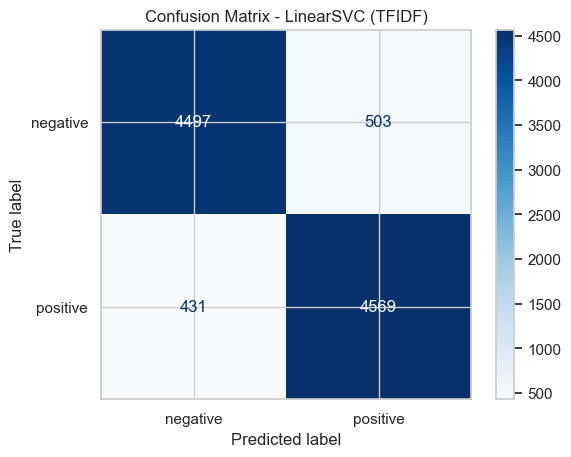

In [12]:
best_name = results_df.loc[0, "model"]
best_obj = next(r for r in runs if r["model"] == best_name)
best_model = best_obj["fitted_model"]
best_pred = best_obj["test_pred"]

print("Best classical model:", best_name)
print(classification_report(y_test, best_pred, target_names=["negative", "positive"]))

cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"]).plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

## 10. NLP Error Analysis and Feature Interpretation

In [13]:
analysis_df = pd.DataFrame({
    "review": X_test_raw.values,
    "clean_review": X_test_clean.values,
    "true": y_test.values,
    "pred": best_pred,
})

misclassified = analysis_df[analysis_df["true"] != analysis_df["pred"]].copy()
misclassified["true_label"] = misclassified["true"].map({0: "negative", 1: "positive"})
misclassified["pred_label"] = misclassified["pred"].map({0: "negative", 1: "positive"})

print("Misclassified examples:", len(misclassified))
misclassified[["true_label", "pred_label", "review"]].head(10)

Misclassified examples: 934


,true_label,pred_label,review
1,positive,negative,"There is so much that can be said about this film. It is not your typical nunsploitation. Of course, there is nudity and sex with nuns, ..."
2,negative,positive,"35 years after this was made, Castro still reigns. Unfortunately, we're left scratching our heads wondering how the dim-witted maniac pl..."
5,positive,negative,"I came out of ""Rendition"" with a list of flaws a mile long, so how is it that my overall impression is that it was a pretty decent movie..."
9,positive,negative,"""The Blob"" qualifies as a cult sci-fi film not only because it launched 27-year old Steve McQueen on a trajectory to superstardom, but a..."
15,positive,negative,"There is this private campground in Plymouth, Massachusetts, that's been around since 1959. My grandparents were among its founders, my ..."
22,negative,positive,When evaluating documentaries that focus a relatively small group of Ugly ultra right wing and conservative groups like this in the USA ...
69,negative,positive,If you have plenty of time to kill and the DVD was given to you by your friend for free but still it may require lot of courage to watch...
83,positive,negative,"Valentine ""Dogkiller"" Dussaut and Joe ""The Judge"" Kern join forces to clean up the mean streets of Geneva! Thrill as they put the kibosh..."
87,negative,positive,A British teen movies which centres around a girl (Justine) accidentally creating her dream man (Jake) in by the use of a virtual realit...
98,negative,positive,It is so rare that I get to rate a movie without having some reservation as to whether I should have gone up one or down one but this on...


In [14]:
if "LogReg" in best_name:
    model = best_model
    feature_names = tfidf.get_feature_names_out()
    coefs = model.coef_[0]

    top_pos_idx = np.argsort(coefs)[-20:][::-1]
    top_neg_idx = np.argsort(coefs)[:20]

    top_pos = pd.DataFrame({"feature": feature_names[top_pos_idx], "weight": coefs[top_pos_idx]})
    top_neg = pd.DataFrame({"feature": feature_names[top_neg_idx], "weight": coefs[top_neg_idx]})

    print("Top positive sentiment features")
    display(top_pos)
    print("Top negative sentiment features")
    display(top_neg)
else:
    print("Top-feature interpretation is shown for logistic regression coefficients.")

Top-feature interpretation is shown for logistic regression coefficients.


## 11. Deep Learning Models: RNN, LSTM, and Small Transformer

This section adds neural baselines and compares them with classical NLP models.

For faster runtime in class/demo, we train on a manageable subset while preserving label balance.

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import precision_recall_fscore_support

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def eval_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
    return acc, p, r, f1

Using device: cpu


In [16]:
# Keep DL part lightweight by subsetting while preserving balance.
train_dl_df = pd.concat([
    pd.DataFrame({"text": X_train_clean, "label": y_train})[y_train == 0].sample(5000, random_state=SEED),
    pd.DataFrame({"text": X_train_clean, "label": y_train})[y_train == 1].sample(5000, random_state=SEED),
]).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

val_dl_df = pd.concat([
    pd.DataFrame({"text": X_val_clean, "label": y_val})[y_val == 0].sample(min(1000, (y_val == 0).sum()), random_state=SEED),
    pd.DataFrame({"text": X_val_clean, "label": y_val})[y_val == 1].sample(min(1000, (y_val == 1).sum()), random_state=SEED),
]).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

test_dl_df = pd.concat([
    pd.DataFrame({"text": X_test_clean, "label": y_test})[y_test == 0].sample(min(1000, (y_test == 0).sum()), random_state=SEED),
    pd.DataFrame({"text": X_test_clean, "label": y_test})[y_test == 1].sample(min(1000, (y_test == 1).sum()), random_state=SEED),
]).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print(train_dl_df.shape, val_dl_df.shape, test_dl_df.shape)

(10000, 2) (2000, 2) (2000, 2)


In [17]:
MAX_LEN = 200
MAX_VOCAB = 20000
BATCH_SIZE = 64
EPOCHS = 3


def basic_tokenize(text):
    return text.split()

counter = Counter()
for text in train_dl_df["text"]:
    counter.update(basic_tokenize(text))

most_common = counter.most_common(MAX_VOCAB - 2)
itos = ["<PAD>", "<UNK>"] + [w for w, _ in most_common]
stoi = {w: i for i, w in enumerate(itos)}
PAD_IDX = stoi["<PAD>"]
UNK_IDX = stoi["<UNK>"]


def encode_text(text, max_len=MAX_LEN):
    ids = [stoi.get(tok, UNK_IDX) for tok in basic_tokenize(text)]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids = ids + [PAD_IDX] * (max_len - len(ids))
    return ids


class TextDataset(Dataset):
    def __init__(self, df):
        self.texts = df["text"].tolist()
        self.labels = df["label"].astype(int).tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = torch.tensor(encode_text(self.texts[idx]), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y


train_loader = DataLoader(TextDataset(train_dl_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TextDataset(val_dl_df), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TextDataset(test_dl_df), batch_size=BATCH_SIZE, shuffle=False)

print("Vocab size:", len(itos))

Vocab size: 20000


In [18]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.rnn(emb)
        last = out[:, -1, :]
        return self.fc(last).squeeze(1)


class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        last = out[:, -1, :]
        return self.fc(last).squeeze(1)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1), :]


class SmallTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, nhead=4, num_layers=2, ff_dim=256, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.pos_encoder = PositionalEncoding(embed_dim)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        emb = self.embedding(x)
        emb = self.pos_encoder(emb)
        out = self.encoder(emb)
        pooled = out.mean(dim=1)
        return self.fc(pooled).squeeze(1)

In [19]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)


def predict_loader(model, loader):
    model.eval()
    probs = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            p = torch.sigmoid(logits).cpu().numpy()
            probs.extend(p.tolist())
            trues.extend(yb.numpy().tolist())
    probs = np.array(probs)
    preds = (probs >= 0.5).astype(int)
    return np.array(trues).astype(int), preds, probs


def train_and_eval_dl(model_name, model, epochs=EPOCHS, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        yv, pv, probv = predict_loader(model, val_loader)
        val_f1 = f1_score(yv, pv)
        print(f"{model_name} | epoch {epoch}/{epochs} | train_loss={tr_loss:.4f} | val_f1={val_f1:.4f}")

    yt, pt, probt = predict_loader(model, test_loader)
    acc, p, r, f1 = eval_metrics(yt, pt)
    auc = roc_auc_score(yt, probt)

    return {
        "model": model_name,
        "test_accuracy": acc,
        "test_precision": p,
        "test_recall": r,
        "test_f1": f1,
        "test_roc_auc": auc,
    }

In [20]:
dl_results = []

rnn_model = RNNClassifier(vocab_size=len(itos), embed_dim=128, hidden_dim=128)
dl_results.append(train_and_eval_dl("RNN (PyTorch)", rnn_model, epochs=EPOCHS, lr=1e-3))

lstm_model = LSTMClassifier(vocab_size=len(itos), embed_dim=128, hidden_dim=128)
dl_results.append(train_and_eval_dl("LSTM (PyTorch)", lstm_model, epochs=EPOCHS, lr=1e-3))

tr_model = SmallTransformerClassifier(vocab_size=len(itos), embed_dim=128, nhead=4, num_layers=2, ff_dim=256)
dl_results.append(train_and_eval_dl("Small Transformer (PyTorch)", tr_model, epochs=EPOCHS, lr=1e-3))

dl_results_df = pd.DataFrame(dl_results).sort_values("test_f1", ascending=False).reset_index(drop=True)
dl_results_df

RNN (PyTorch) | epoch 1/3 | train_loss=0.6968 | val_f1=0.1778
RNN (PyTorch) | epoch 2/3 | train_loss=0.6840 | val_f1=0.6454
RNN (PyTorch) | epoch 3/3 | train_loss=0.6801 | val_f1=0.5661
LSTM (PyTorch) | epoch 1/3 | train_loss=0.6934 | val_f1=0.1623
LSTM (PyTorch) | epoch 2/3 | train_loss=0.6825 | val_f1=0.6341
LSTM (PyTorch) | epoch 3/3 | train_loss=0.6592 | val_f1=0.6375
Small Transformer (PyTorch) | epoch 1/3 | train_loss=0.6065 | val_f1=0.7476
Small Transformer (PyTorch) | epoch 2/3 | train_loss=0.4421 | val_f1=0.7657
Small Transformer (PyTorch) | epoch 3/3 | train_loss=0.3522 | val_f1=0.8056


,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Small Transformer (PyTorch),0.8160,0.836887,0.785,0.810114,0.902912
1,LSTM (PyTorch),0.5015,0.500807,0.931,0.651277,0.520661
2,RNN (PyTorch),0.5015,0.501151,0.653,0.567086,0.512970


## 12. Final Comparison: Every Model (Classical + Deep Learning)

In [21]:
classical_for_merge = results_df[[
    "model", "test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"
]].copy()
classical_for_merge["family"] = "Classical NLP"

dl_for_merge = dl_results_df.copy()
dl_for_merge["family"] = "Deep Learning"

all_models_df = pd.concat([classical_for_merge, dl_for_merge], ignore_index=True)
all_models_df = all_models_df.sort_values("test_f1", ascending=False).reset_index(drop=True)

all_models_df

,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,family
0,LinearSVC (TFIDF),0.9066,0.900828,0.9138,0.907268,0.967190,Classical NLP
1,LogReg (TFIDF),0.9061,0.897592,0.9168,0.907094,0.966403,Classical NLP
2,SGDClassifier (TFIDF),0.9045,0.893100,0.9190,0.905865,0.964380,Classical NLP
3,MultinomialNB (TFIDF),0.8864,0.880465,0.8942,0.887279,0.952582,Classical NLP
4,MultinomialNB (BoW),0.8775,0.877123,0.8780,0.877561,0.938611,Classical NLP
5,Small Transformer (PyTorch),0.8160,0.836887,0.7850,0.810114,0.902912,Deep Learning
6,LSTM (PyTorch),0.5015,0.500807,0.9310,0.651277,0.520661,Deep Learning
7,RNN (PyTorch),0.5015,0.501151,0.6530,0.567086,0.512970,Deep Learning


C:\Users\2004l\AppData\Local\Temp\ipykernel_36464\1076464134.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank_plot_df, x="model_display", y="test_f1", palette="viridis")


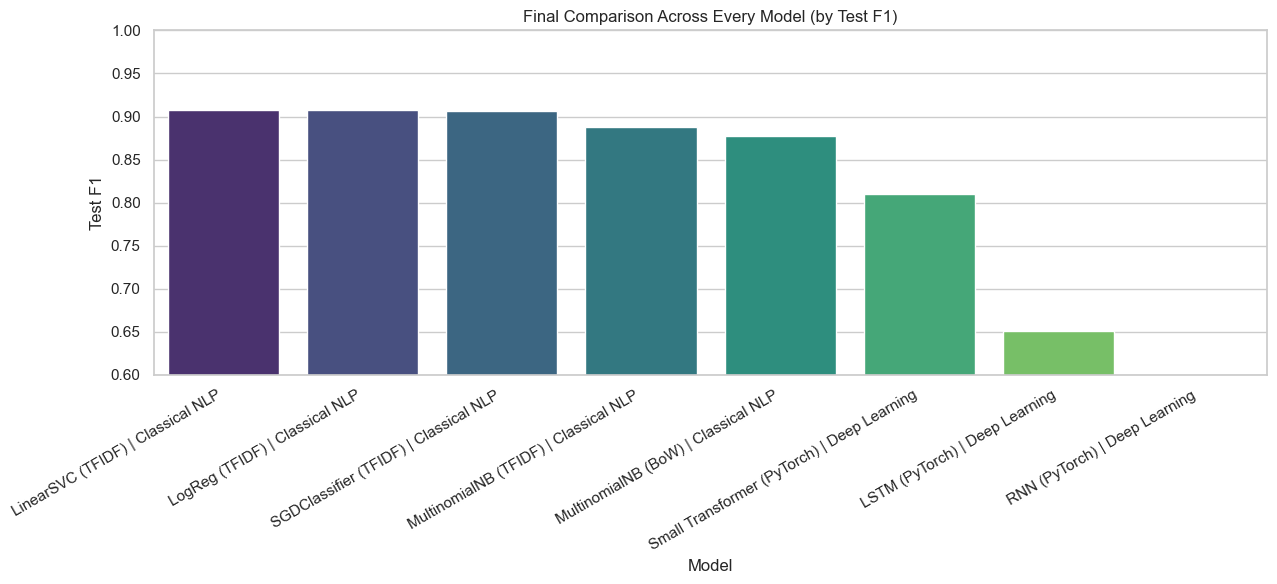

In [22]:
plt.figure(figsize=(13, 6))
rank_plot_df = all_models_df.copy()
rank_plot_df["model_display"] = rank_plot_df["model"] + " | " + rank_plot_df["family"]

sns.barplot(data=rank_plot_df, x="model_display", y="test_f1", palette="viridis")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.6, 1.0)
plt.title("Final Comparison Across Every Model (by Test F1)")
plt.xlabel("Model")
plt.ylabel("Test F1")
plt.tight_layout()
plt.show()